/tmp/ipykernel_10426/82511640.py:34: UserWarning: Legend does not support handles for str instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries
  plt.legend('N1', 'N2')


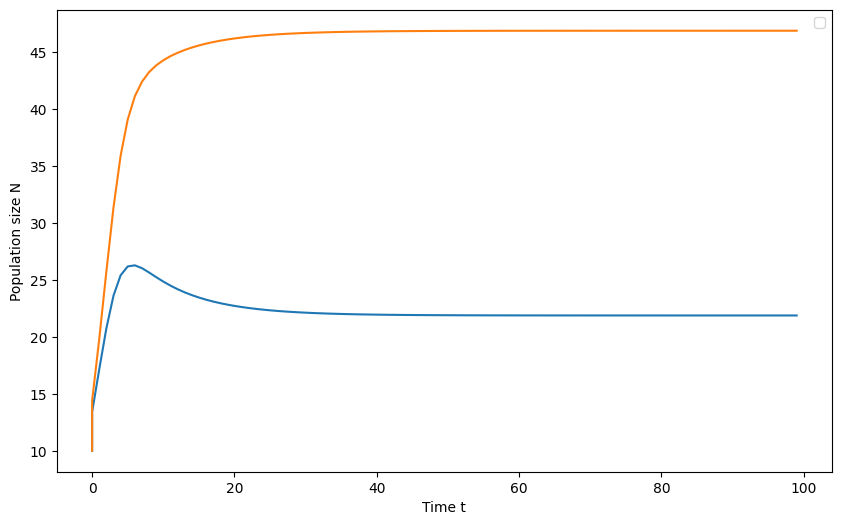

In [ ]:
import matplotlib.pyplot as plt

r1 = 0.5
r2 = 0.6
K1 = 50
K2 = 60
b12 = 0.6
b21 = 0.6


N1 = 10
N2 = 10
T = 100
N1_list = [N1]
N2_list = [N2]
t_list = [0]

for t in range(T):
  dN1 = r1 * N1 * (K1 - N1 - b12 * N2)/ K1
  dN2 = r2 * N2 * (K2 - N2 - b21 * N1)/ K2
  N1 = N1 + dN1
  N2 = N2 + dN2

  N1_list.append(N1)
  N2_list.append(N2)
  t_list.append(t)

plt.figure(figsize=(10, 6))
plt.plot(t_list, N1_list)
plt.plot(t_list, N2_list)

plt.xlabel('Time t')
plt.ylabel('Population size N')
plt.legend('N1', 'N2')

plt.show()





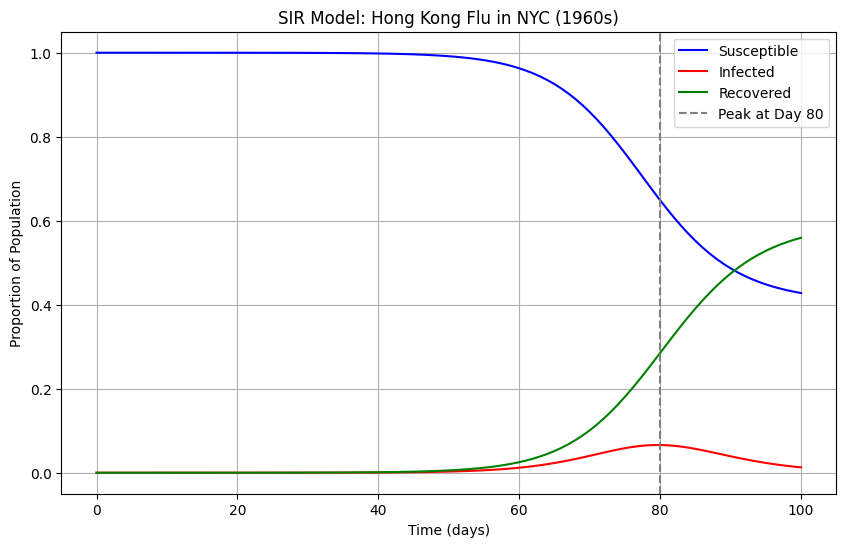

In [ ]:
import matplotlib.pyplot as plt

N = 7900000
I0 = 10
S0 = N - I0
R0_pop = 0

beta = 0.5
gamma = 1/3

s = S0 / N
i = I0 / N
r = R0_pop / N

s_list = [s]
i_list = [i]
r_list = [r]
t_list = [0]

curr_s = s
curr_i = i
curr_r = r

for t in range(1, T + 1):
    ds = - beta * curr_s * curr_i
    di = beta * curr_s * curr_i - gamma * curr_i
    dr = gamma * curr_i

    curr_s += ds
    curr_i += di
    curr_r += dr

    s_list.append(curr_s)
    i_list.append(curr_i)
    r_list.append(curr_r)
    t_list.append(t)

peak_i = max(i_list)
peak_day = t_list[i_list.index(peak_i)]

plt.figure(figsize=(10, 6))
plt.plot(t_list, s_list, label='Susceptible', color='blue')
plt.plot(t_list, i_list, label='Infected', color='red')
plt.plot(t_list, r_list, label='Recovered', color='green')

plt.axvline(x=peak_day, color='gray', linestyle='--', label=f'Peak at Day {peak_day}')

plt.xlabel('Time (days)')
plt.ylabel('Proportion of Population')
plt.title('SIR Model: Hong Kong Flu in NYC (1960s)')
plt.legend()
plt.grid(True)
plt.savefig('sir_model_nyc.png')

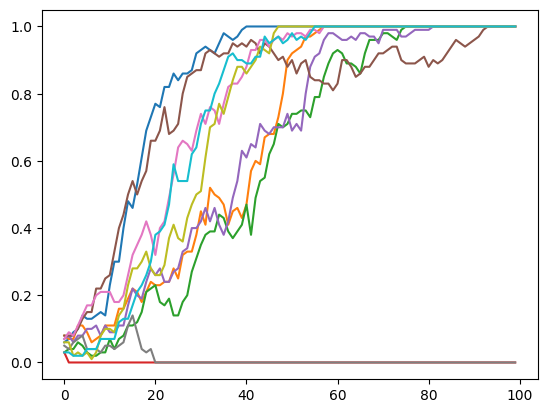

In [ ]:
import matplotlib.pyplot as plt
import random
from random import sample
replicate = 10

for r in range(replicate):

  N = 100
  g = 100
  s_d = 0.9
  s_l = 0.8
  f = 3
  p_d = 0.05
  p_l = 1 - p_d
  N_d = int(p_d*N)
  pop = ['d']*N_d + ['l']*(N-N_d)
  p_d_list =[]
  i_list = []
  for i in range(g):
    offspring = []
    for t in pop:
      a = random.random()
      if t == 'd' and a < 0.9:
        offspring = offspring + [t] * f
      elif t == 'l' and a < 0.8:
        offspring = offspring + [t] * f
      #print(offspring)
    pop = sample(offspring, N)
      #print(pop)
    pop.count('d') #counts the number of d in the list
    p_d = pop.count('d')/N
    p_d_list.append(p_d)
    i_list.append(i)
  #print(p_d_list)
  plt.plot(i_list,p_d_list)






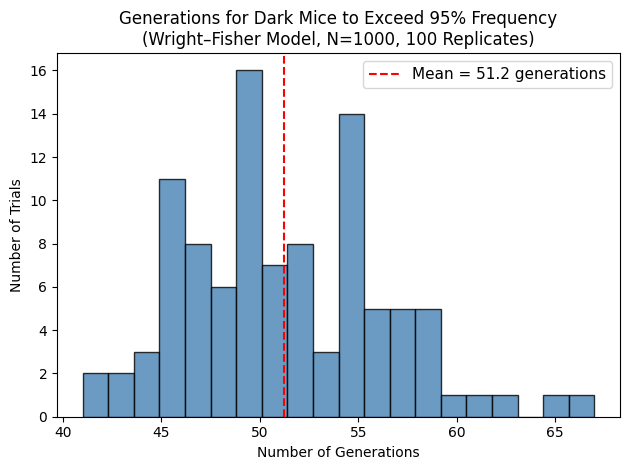

Mean generations:   51.25
Min generations:    41
Max generations:    67
Mean number of generations:     51.25
Variance of generations:        25.89


In [ ]:
import matplotlib.pyplot as plt
import random
from random import sample
import numpy as np

N = 1000
s_d = 0.9
s_l = 0.8
f = 3
p_d_initial = 0.05
replicates = 100
threshold = 0.95
generations_required = []

for r in range(replicates):
    N_d = int(p_d_initial * N)
    pop = ['d'] * N_d + ['l'] * (N - N_d)
    generations = 0
    p_d = p_d_initial
    while p_d <= threshold:
        generations += 1
        offspring = []
        for t in pop:
            a = random.random()
            if t == 'd' and a < s_d:
                offspring += ['d'] * f
            elif t == 'l' and a < s_l:
                offspring += ['l'] * f
        if len(offspring) == 0:
            break
        pop = sample(offspring, min(N, len(offspring)))
        p_d = pop.count('d') / len(pop)
        if p_d == 0.0:
            break
    generations_required.append(generations)

plt.hist(generations_required, bins=20, color='steelblue',
         edgecolor='black', alpha=0.8)
plt.xlabel('Number of Generations')
plt.ylabel('Number of Trials')
plt.title('Generations for Dark Mice to Exceed 95% Frequency\n'
          '(Wright–Fisher Model, N=1000, 100 Replicates)')
plt.axvline(sum(generations_required) / len(generations_required),
            color='red', linestyle='--', linewidth=1.5,
            label=f'Mean = {sum(generations_required)/len(generations_required):.1f} generations')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f"Mean generations:   {sum(generations_required)/len(generations_required):.2f}")
print(f"Min generations:    {min(generations_required)}")
print(f"Max generations:    {max(generations_required)}")
mean_gen = np.mean(generations_required)
var_gen  = np.var(generations_required, ddof=1)

print(f"Mean number of generations:     {mean_gen:.2f}")
print(f"Variance of generations:        {var_gen:.2f}")